In [1]:
# Step 1: 安装必要的库（如果尚未安装）
# %pip install akshare scikit-learn xgboost matplotlib pandas numpy ipywidgets --upgrade

# Step 2: 导入所有需要的模块
import akshare as ak
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt

In [2]:
# Step 3: 获取最近三个月的ETF历史数据
def fetch_etf_data(symbol):
    end_date = datetime.today().strftime("%Y%m%d")
    start_date = (datetime.today() - timedelta(days=90)).strftime("%Y%m%d")

    etf_df = ak.fund_etf_hist_em(symbol=symbol,
                                 period="daily",
                                 start_date=start_date,
                                 end_date=end_date,
                                 adjust="")
    
    print("原始ETF数据列名如下：")  # 调试信息
    print(etf_df.columns.tolist())  # 查看真实列名
    
    # 根据实际列名修改下面的映射
    column_mapping = {
        "日期": "日期",
        "开盘": "开盘",
        "最高": "最高",
        "最低": "最低",
        "收盘": "收盘",
        "成交量": "成交量"
    }

    selected_columns = {k: v for k, v in column_mapping.items() if k in etf_df.columns}
    etf_df = etf_df[selected_columns.keys()].rename(columns=selected_columns)

    etf_df['日期'] = pd.to_datetime(etf_df['日期'])
    return etf_df.sort_values('日期').reset_index(drop=True)

In [3]:
# Step 4: 特征工程
def prepare_features(df):
    df = df.copy()
    window = 5  # 使用5日均线作为特征

    # 确保“日期”列为 datetime 类型，并设为索引
    df['日期'] = pd.to_datetime(df['日期'])
    df.set_index('日期', inplace=True)

    # 添加滞后特征：收盘价滞后1~5天
    for lag in range(1, 6):
        df[f'收盘_滞后{lag}'] = df['收盘'].shift(lag)

    # 添加技术指标
    df[f'SMA_{window}'] = df['收盘'].rolling(window=window).mean()
    df['Volatility'] = df['最高'] - df['最低']

    # 删除缺失值
    df.dropna(inplace=True)

    # 特征列和目标变量
    feature_cols = [col for col in df.columns if col not in ['收盘']]
    X = df[feature_cols]
    y = df['收盘']

    # 返回价格 DataFrame 时也带上日期（索引）
    price_df = df[['收盘']].rename(columns={'收盘': '收盘价'})

    return X, y, price_df

In [4]:
# Step 5: 训练多个模型（共6个）
def train_models(X_train, y_train):
    models = {}
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    models["Decision Tree"] = (DecisionTreeRegressor(max_depth=5, random_state=42).fit(X_train_scaled, y_train), scaler)
    models["Random Forest"] = (RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42).fit(X_train_scaled, y_train), scaler)
    models["XGBoost"] = (XGBRegressor(n_estimators=100, max_depth=3, random_state=42, enable_categorical=True).fit(X_train_scaled, y_train), scaler)
    models["SVR"] = (SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1).fit(X_train_scaled, y_train), scaler)
    models["KNN"] = (KNeighborsRegressor(n_neighbors=5).fit(X_train_scaled, y_train), scaler)
    models["MLP"] = (MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42).fit(X_train_scaled, y_train), scaler)

    return models


In [5]:
# Step 6: 预测未来10天的价格
def predict_future(models_dict, last_row, current_date=None, horizon=10):
    predictions = []
    current_data = last_row.copy()

    # 确保滞后列存在
    for lag in range(1, 6):
        col_name = f'收盘_滞后{lag}'
        if col_name not in current_data:
            raise KeyError(f"缺失滞后列：{col_name}")

    # 开始预测
    for _ in range(horizon):
        preds = []
        for name, (model, scaler) in models_dict.items():
            scaled_data = scaler.transform([current_data])
            pred = model.predict(scaled_data)[0]
            preds.append(pred)

        avg_pred = np.mean(preds)
        predictions.append(avg_pred)

        # 更新滞后特征（从滞后4 -> 滞后5，滞后3 -> 滞后4...）
        for lag in range(4, 0, -1):
            current_data[f'收盘_滞后{lag + 1}'] = current_data[f'收盘_滞后{lag}']
        current_data[f'收盘_滞后1'] = avg_pred  # 设置最新预测值为滞后1

        # 更新SMA_5
        sma_vals = [avg_pred] + list(current_data[[f'收盘_滞后{i}' for i in range(2, 6)]])
        current_data['SMA_5'] = np.mean(sma_vals)

    # 获取当前日期
    if current_date is None:
        try:
            current_date = pd.to_datetime(current_data.name)
        except Exception as e:
            print("无法解析 current_data.name 为日期，使用 today 替代")
            current_date = pd.to_datetime(datetime.now().date())

    # 生成未来交易日（排除周末）
    future_dates = pd.date_range(start=current_date + pd.Timedelta(days=1), periods=horizon, freq='B')

    # 构造结果 DataFrame
    pred_df = pd.DataFrame(
        predictions,
        index=future_dates,
        columns=["预测收盘价"]
    )

    return pred_df

In [6]:
# Step 7: 可视化预测结果
import matplotlib.pyplot as plt

def plot_predictions(history_df, future_df):
    plt.figure(figsize=(14, 7))
    
    # 使用索引（日期）进行绘图
    plt.plot(history_df.index, history_df['收盘价'], label='历史价格', color='blue')
    
    colors = ['red', 'green', 'orange', 'purple', 'brown', 'cyan']
    for (name, values), color in zip(future_df.items(), colors):
        plt.plot(values.index, values.values, label=name, color=color)
    
    plt.title('ETF价格预测')
    plt.xlabel('日期')
    plt.ylabel('价格')
    plt.legend()
    plt.show()

In [7]:
# Step 8: 主函数
def main(symbol):
    print(f"正在获取ETF {symbol} 最近3个月的历史数据...")
    df = fetch_etf_data(symbol)

    print("特征工程处理中...")
    X, y, price_df = prepare_features(df)

    print("划分训练集和测试集...")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    print("训练多个机器学习模型（共6个）...")
    models = train_models(X_train, y_train)

    print("提取最后一天特征用于预测...")
    last_row = X.iloc[-1].copy()

    print("预测未来10个交易日的价格...")
    future_pred = predict_future(models, last_row)

    print("\n未来10个交易日的预测收盘价：")
    print(future_pred)
    max_p=future_pred['预测收盘价'].max()
    min_p=future_pred['预测收盘价'].min()
    dif_p=max_p-min_p
    print(f"最高价为{max_p}")
    print(f"最低价为{min_p}")
    print(f"差价为{dif_p}")
    print(f"合适卖出价为{max_p-dif_p*0.2}")

    print("绘图展示预测结果...")
    plot_predictions(price_df, future_pred)

正在获取ETF 515880 最近3个月的历史数据...


  0%|          | 0/10 [00:00<?, ?it/s]

原始ETF数据列名如下：
['日期', '开盘', '收盘', '最高', '最低', '成交量', '成交额', '振幅', '涨跌幅', '涨跌额', '换手率']
特征工程处理中...
划分训练集和测试集...
训练多个机器学习模型（共6个）...
提取最后一天特征用于预测...
预测未来10个交易日的价格...

未来10个交易日的预测收盘价：
               预测收盘价
2025-07-08  1.396515
2025-07-09  1.422333
2025-07-10  1.428785
2025-07-11  1.402686
2025-07-14  1.404288
2025-07-15  1.420141
2025-07-16  1.405454
2025-07-17  1.397678
2025-07-18  1.413066
2025-07-21  1.410821
最高价为1.428784701002843
最低价为1.3965146253717406
差价为0.03227007563110229
合适卖出价为1.4223306858766225
绘图展示预测结果...


C:\Users\15601\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\15601\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\15601\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\15601\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-pac

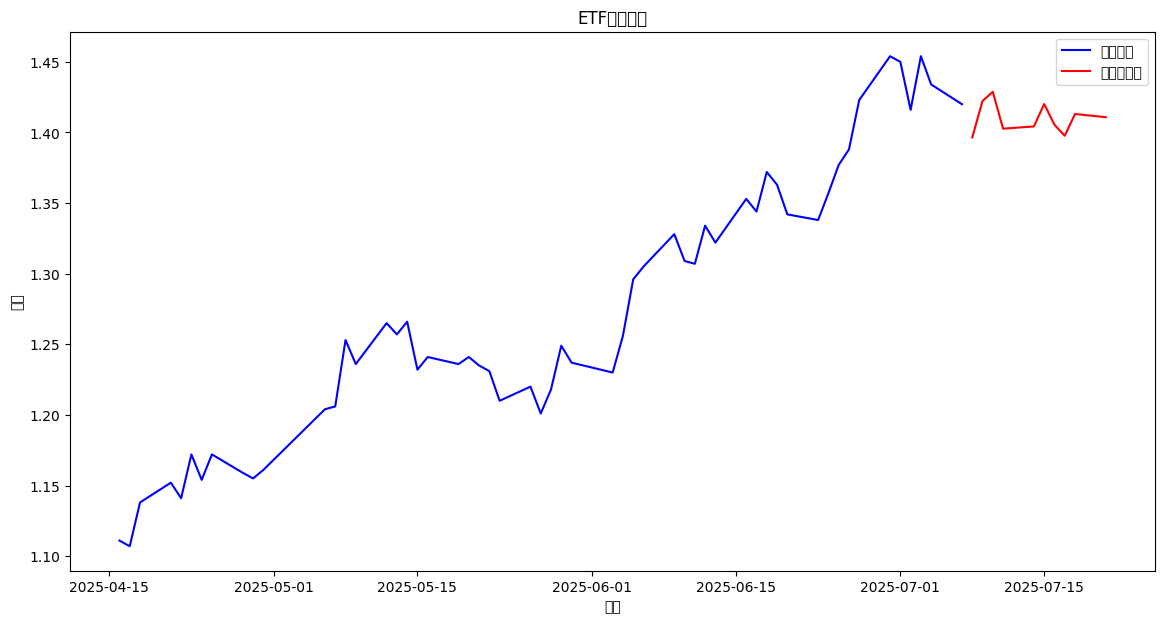

In [8]:
# Step 9: 用户输入ETF代码并运行
if __name__ == "__main__":
    symbol = input("请输入ETF代码（例如：513500）：").strip()
    main(symbol)